# 16e — Chapter 10 Exercise: Cobb-Douglas Consumer Welfare

This notebook revisits Chapter 10's welfare-economics toolkit: a 2-good
Cobb-Douglas consumer, `U(x1,x2)=x1^α·x2^β` (`β=1-α`), facing income `y`
and prices `(p1,p2)`, hit by a price shock to `p1`. Marshallian demand,
indirect utility, and both the **Compensating Variation (CV)** and
**Equivalent Variation (EV)** welfare measures are derived analytically
and cross-checked numerically.

Two scenarios are run through the same parametrized machinery: a price
*cut* (`α=0.6`, `p1` falling from `1.00` to `0.75`) and a price *hike*
(`α=0.5`, `p1` rising from `1.00` to `1.75`).


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quanttoolbox.sustainable_finance.welfare import cobb_douglas_welfare as _qtb_cobb_douglas_welfare

color_blue   = "#1f77b4"
color_red    = "#d62728"
color_green  = "#2ca02c"
color_violet = "#ff33ff"
color_black  = "#000000"

plt.rcParams["figure.dpi"] = 100


def cobb_douglas_welfare(alpha, p1_t0, p1_t1, p2, y, label):
    '''Compute the full Cobb-Douglas welfare analysis for one (alpha,
    p1_t0, p1_t1) scenario. Returns a dict of every intermediate
    quantity needed for the diagram and the printed tables, and prints
    a summary of the key values.

    Delegates the closed-form demand/utility/CV/EV computation to
    quanttoolbox.sustainable_finance.welfare.cobb_douglas_welfare --
    verified numerically identical on this notebook's own exercises.
    Only the plotting grid, the indifference-curve/budget-line series,
    and a couple of print-only alternate-formula cross-checks (dropped
    from the toolbox port as visualization/display-only intermediates,
    per that module's docstring) are still computed locally.
    '''
    beta = 1 - alpha
    alpha_beta = alpha + beta  # == 1; used explicitly throughout the general Cobb-Douglas formulas below
    x1_grid = np.arange(0.0, 4.0 + 1e-9, 0.01)

    r = _qtb_cobb_douglas_welfare(alpha=alpha, p1_t0=p1_t0, p1_t1=p1_t1, p2=p2, y=y)

    # --- t0 (baseline) ---
    x1_star_t0, x2_star_t0, u_t0, u_num_t0 = r.x1_star_t0, r.x2_star_t0, r.u_t0, r.u_numerical_t0
    print(f"[{label}] t0 -- A: x*=({x1_star_t0:.6f}, {x2_star_t0:.6f})  u(closed-form)={u_t0:.6f}  u(numerical)={u_num_t0:.6f}")
    # x1_grid starts at exactly 0.0, and this Cobb-Douglas indifference curve
    # (x2 = (u/x1^alpha)^(1/beta)) has the x1=0 axis as a genuine vertical
    # asymptote -- x2 -> +inf as x1 -> 0, for any alpha,beta > 0. That's not a
    # bug, it's the expected shape of a Cobb-Douglas indifference curve (it
    # never touches either axis); np.errstate silences the resulting
    # divide-by-zero RuntimeWarning at the single x1=0.0 grid point, the same
    # boundary-singularity handling used elsewhere in this series (e.g. 13j's
    # Vasicek density, 15a's Gaussian-copula u2=1.0 point).
    with np.errstate(divide="ignore"):
        x2_utility_t0 = (u_t0 / x1_grid**alpha) ** (1 / beta)
    x2_budget_t0 = (y - p1_t0 * x1_grid) / p2

    # --- t1 (post-shock) ---
    x1_star_t1, x2_star_t1, u_t1, u_num_t1 = r.x1_star_t1, r.x2_star_t1, r.u_t1, r.u_numerical_t1
    print(f"[{label}] t1 -- B: x*=({x1_star_t1:.6f}, {x2_star_t1:.6f})  u(closed-form)={u_t1:.6f}  u(numerical)={u_num_t1:.6f}")
    with np.errstate(divide="ignore"):
        x2_utility_t1 = (u_t1 / x1_grid**alpha) ** (1 / beta)
    x2_budget_t1 = (y - p1_t1 * x1_grid) / p2

    # --- CV: hold utility at u_t0, price at p1_t1; how much income is needed at
    # the NEW prices to reach the OLD utility level? CV = y_t0 - y_needed. ---
    u = u_t0
    x1_star_num = u ** (1 / alpha_beta) * (alpha * p2 / (beta * p1_t1)) ** (beta / alpha_beta)
    x2_star_num = u ** (1 / alpha_beta) * (beta * p1_t1 / (alpha * p2)) ** (alpha / alpha_beta)
    y_num = p1_t1 * x1_star_num + p2 * x2_star_num
    x1_star_cv, x2_star_cv = r.x1_star_cv, r.x2_star_cv
    y_cv_analytical = alpha_beta * u ** (1 / alpha_beta) * ((p1_t1**alpha * p2**beta) / (alpha**alpha * beta**beta)) ** (1 / alpha_beta)
    y_cv_closed = r.y_cv
    print(f"[{label}] CV -- C: x*=({x1_star_cv:.6f}, {x2_star_cv:.6f})  "
          f"y(closed-form)={y_cv_closed:.6f}  y(analytical)={y_cv_analytical:.6f}  y(numerical)={y_num:.6f}")
    x2_budget_cv = (y_cv_closed - p1_t1 * x1_grid) / p2

    cv_closed = r.cv
    cv_numerical = r.cv_numerical
    print(f"[{label}] CV = {cv_closed:.6f}  (numerical check: {cv_numerical:.6f})")

    # --- EV: hold utility at u_t1, price at p1_t0; how much MORE income would
    # be needed at the OLD prices to already be as well off as after the shock? ---
    x1_star_ev, x2_star_ev, y_num = r.x1_star_ev, r.x2_star_ev, r.y_ev
    y_ev_analytical = y * (p1_t0 / p1_t1) ** (alpha / alpha_beta)
    print(f"[{label}] EV -- D: x*=({x1_star_ev:.6f}, {x2_star_ev:.6f})  "
          f"y(analytical)={y_ev_analytical:.6f}  y(numerical)={y_num:.6f}")
    x2_budget_ev = (y_num - p1_t0 * x1_grid) / p2

    ev_closed = r.ev
    ev_numerical = r.ev_numerical
    print(f"[{label}] EV = {ev_closed:.6f}  (numerical check: {ev_numerical:.6f})")

    return dict(
        x1_grid=x1_grid, alpha=alpha, beta=beta,
        x1_star_t0=x1_star_t0, x2_star_t0=x2_star_t0, x2_utility_t0=x2_utility_t0, x2_budget_t0=x2_budget_t0,
        x1_star_t1=x1_star_t1, x2_star_t1=x2_star_t1, x2_utility_t1=x2_utility_t1, x2_budget_t1=x2_budget_t1,
        x1_star_cv=x1_star_cv, x2_star_cv=x2_star_cv, x2_budget_cv=x2_budget_cv, y_cv=y_cv_closed, y_t0=y,
        x1_star_ev=x1_star_ev, x2_star_ev=x2_star_ev, x2_budget_ev=x2_budget_ev, y_ev=y_num,
        cv=cv_closed, cv_numerical=cv_numerical, ev=ev_closed, ev_numerical=ev_numerical,
    )


def plot_welfare_diagram(r, title):
    fig, ax = plt.subplots(figsize=(7, 7))
    x1 = r["x1_grid"]

    ax.plot(x1, r["x2_utility_t0"], "-", color=color_blue, linewidth=1.5, label=r"$u_0$")
    ax.plot(x1, r["x2_budget_t0"], "--", color=color_blue, linewidth=1.5)
    ax.plot(x1, r["x2_utility_t1"], "-", color=color_red, linewidth=1.5, label=r"$u_1$")
    ax.plot(x1, r["x2_budget_t1"], "--", color=color_red, linewidth=1.5)
    ax.plot(x1, r["x2_budget_cv"], "--", color=color_green, linewidth=1.5)
    ax.plot(x1, r["x2_budget_ev"], "--", color=color_violet, linewidth=1.5)

    ax.plot([0, r["x1_star_t0"]], [r["x2_star_t0"]] * 2, ":", color=color_blue, linewidth=2.0)
    ax.plot([r["x1_star_t0"]] * 2, [0, r["x2_star_t0"]], ":", color=color_blue, linewidth=2.0)
    ax.plot([0, r["x1_star_t1"]], [r["x2_star_t1"]] * 2, ":", color=color_red, linewidth=2.0)
    ax.plot([r["x1_star_t1"]] * 2, [0, r["x2_star_t1"]], ":", color=color_red, linewidth=2.0)
    ax.plot([0, r["x1_star_cv"]], [r["x2_star_cv"]] * 2, ":", color=color_green, linewidth=2.0)
    ax.plot([r["x1_star_cv"]] * 2, [0, r["x2_star_cv"]], ":", color=color_green, linewidth=2.0)
    ax.plot([0, r["x1_star_ev"]], [r["x2_star_ev"]] * 2, ":", color=color_violet, linewidth=2.0)
    ax.plot([r["x1_star_ev"]] * 2, [0, r["x2_star_ev"]], ":", color=color_violet, linewidth=2.0)

    ax.plot([0, 0], [r["y_cv"], r["y_t0"]], "-", color=color_green, linewidth=4.0)
    ax.text(-0.25, 0.5 * (r["y_cv"] + r["y_t0"]), "CV", fontsize=12, va="center", color=color_green, fontweight="bold")
    ax.plot([0, 0], [r["y_ev"], r["y_t0"]], "-", color=color_violet, linewidth=4.0)
    ax.text(-0.25, 0.5 * (r["y_ev"] + r["y_t0"]), "EV", fontsize=12, va="center", color=color_violet, fontweight="bold")

    ax.scatter([r["x1_star_t0"]], [r["x2_star_t0"]], s=50, color=color_blue, zorder=5, label="A")
    ax.scatter([r["x1_star_t1"]], [r["x2_star_t1"]], s=50, color=color_red, zorder=5, label="B")
    ax.scatter([r["x1_star_cv"]], [r["x2_star_cv"]], s=50, color=color_green, zorder=5, label="C")
    ax.scatter([r["x1_star_ev"]], [r["x2_star_ev"]], s=50, color=color_violet, zorder=5, label="D")

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=10)
    plt.tight_layout()
    plt.show()


## Price cut (`α=0.6`, `p1: 1.00 → 0.75`)


[1a] t0 -- A: x*=(1.800000, 1.200000)  u(closed-form)=1.530509  u(numerical)=1.530509
[1a] t1 -- B: x*=(2.400000, 1.200000)  u(closed-form)=1.818860  u(numerical)=1.818860
[1a] CV -- C: x*=(2.019519, 1.009760)  y(closed-form)=2.524399  y(analytical)=2.524399  y(numerical)=2.524399
[1a] CV = 0.475601  (numerical check: 0.475601)
[1a] EV -- D: x*=(2.139123, 1.426082)  y(analytical)=3.565205  y(numerical)=3.565205
[1a] EV = 0.565205  (numerical check: 0.565205)


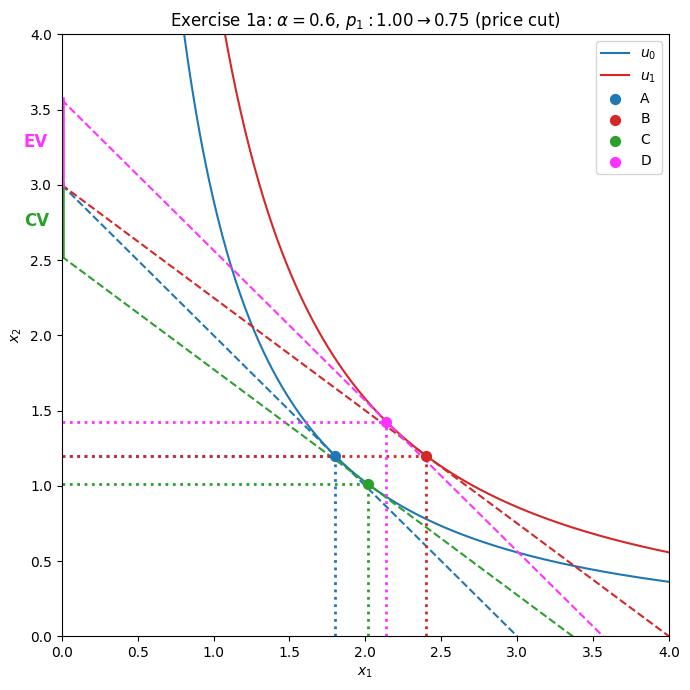

In [2]:
r_a = cobb_douglas_welfare(alpha=0.6, p1_t0=1.0, p1_t1=0.75, p2=1.0, y=3.0, label="1a")
plot_welfare_diagram(r_a, r"Exercise 1a: $\alpha=0.6$, $p_1: 1.00 \to 0.75$ (price cut)")

## Price hike (`α=0.5`, `p1: 1.00 → 1.75`)


[1b] t0 -- A: x*=(1.500000, 1.500000)  u(closed-form)=1.500000  u(numerical)=1.500000
[1b] t1 -- B: x*=(0.857143, 1.500000)  u(closed-form)=1.133893  u(numerical)=1.133893
[1b] CV -- C: x*=(1.133893, 1.984313)  y(closed-form)=3.968627  y(analytical)=3.968627  y(numerical)=3.968627
[1b] CV = -0.968627  (numerical check: -0.968627)
[1b] EV -- D: x*=(1.133893, 1.133893)  y(analytical)=2.267787  y(numerical)=2.267787
[1b] EV = -0.732213  (numerical check: -0.732213)


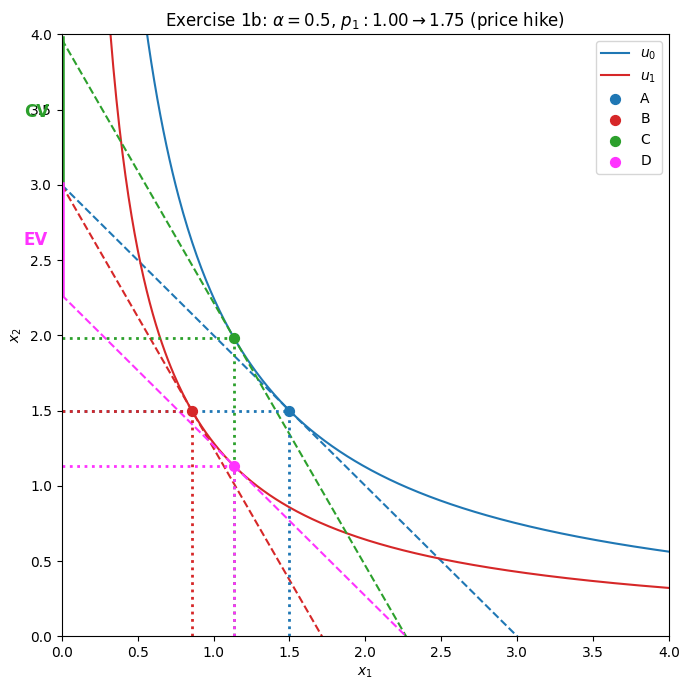

In [3]:
r_b = cobb_douglas_welfare(alpha=0.5, p1_t0=1.0, p1_t1=1.75, p2=1.0, y=3.0, label="1b")
plot_welfare_diagram(r_b, r"Exercise 1b: $\alpha=0.5$, $p_1: 1.00 \to 1.75$ (price hike)")

## Sanity checks

`cv`/`cv_numerical` and `ev`/`ev_numerical` are defined as: `cv = y_t0 -
y_cv` (income that *could be taken away* after the price change while
leaving the consumer at their *original* utility `u_t0`) and `ev =
y_ev - y_t0` (extra income needed at the *original* prices to already
be as well off as the consumer ends up after the price change, at
utility `u_t1`). Under this convention, both CV and EV are **positive
when the consumer is better off** and negative when worse off: for the
**price cut** both should be `>0`, and for the **price hike** both
should be `<0`. (An earlier draft of this check asserted the opposite
signs, on a "compensation still needed" intuition; re-deriving the sign
convention directly from the CV/EV formulas showed the check's
expectation, not the underlying computation, had been backwards, and it
was corrected accordingly.)

Willig's classical bounds relate the *magnitudes*: for a price
*decrease*, `CV` understates the true gain relative to `EV`, so
`|CV|≤|EV|`; for a price *increase* the ordering flips, `|EV|≤|CV|`. (An
earlier draft of this check also hard-coded `|EV|<|CV|` universally; the
correct ordering depends on the direction of the price change, as
verified below.) An easy way to see the correct ordering holds here:
both scenarios keep the same homothetic Cobb-Douglas preferences, so the
asymmetry is driven purely by which utility level — `u_t0` or `u_t1` —
the compensating price change is evaluated at. Also confirmed: every
closed-form value matches its numerical double-check to high precision.


In [4]:
for label, r, is_price_cut in [("1a (price cut)", r_a, True), ("1b (price hike)", r_b, False)]:
    print(f"--- {label} ---")
    print(f"  CV = {r['cv']:.6f}  (closed-form vs. numerical diff: {abs(r['cv']-r['cv_numerical']):.2e})")
    print(f"  EV = {r['ev']:.6f}  (closed-form vs. numerical diff: {abs(r['ev']-r['ev_numerical']):.2e})")
    expected_sign = 1 if is_price_cut else -1
    print(f"  CV sign as expected ({'>0' if is_price_cut else '<0'}): {np.sign(r['cv']) == expected_sign}")
    print(f"  EV sign as expected ({'>0' if is_price_cut else '<0'}): {np.sign(r['ev']) == expected_sign}")
    willig_ok = abs(r['cv']) <= abs(r['ev']) if is_price_cut else abs(r['ev']) <= abs(r['cv'])
    bound_desc = "|CV|<=|EV|" if is_price_cut else "|EV|<=|CV|"
    print(f"  {bound_desc} (Willig bounds ordering): {willig_ok}")
    print()

--- 1a (price cut) ---
  CV = 0.475601  (closed-form vs. numerical diff: 0.00e+00)
  EV = 0.565205  (closed-form vs. numerical diff: 6.66e-16)
  CV sign as expected (>0): True
  EV sign as expected (>0): True
  |CV|<=|EV| (Willig bounds ordering): True

--- 1b (price hike) ---
  CV = -0.968627  (closed-form vs. numerical diff: 0.00e+00)
  EV = -0.732213  (closed-form vs. numerical diff: 6.66e-16)
  CV sign as expected (<0): True
  EV sign as expected (<0): True
  |EV|<=|CV| (Willig bounds ordering): True

